# Introduction to Data Analysis with Python
## Jupyter Notebooks, Pandas, and NumPy

### Using the Titanic Dataset

---

## Agenda
1. What is Jupyter Notebooks?  
2. Introduction to Pandas DataFrames  
3. NumPy Fundamentals  
4. Wrap-up and Next Steps  

---
## Part 1: Jupyter Notebooks 

### What is Jupyter?

Jupyter Notebooks are **interactive computing environments** that allow you to:
- Write and execute code in chunks (cells)
- Mix code with rich text, equations, and visualizations
- Create reproducible research and analysis
- Share your work easily

### Two Types of Cells:
1. **Markdown cells** (like this one) - for documentation, explanations, headers
2. **Code cells** - for executable Python code

### Key Shortcuts:
- `Shift + Enter` - Run current cell and move to next
- `Ctrl + Enter` - Run current cell and stay
- `Esc` then `A` - Insert cell above
- `Esc` then `B` - Insert cell below
- `Esc` then `M` - Convert to markdown
- `Esc` then `Y` - Convert to code

### Let's Start Coding!

First, we'll import the libraries we need:

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This magic command makes plots appear in the notebook
%matplotlib inline

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.4


## Part 2: Pandas DataFrames  

### What is Pandas?

**Pandas** is Python's premier data manipulation library. It provides:
- **DataFrames**: 2D labeled data structures (think Excel spreadsheets in Python)
- **Series**: 1D labeled arrays (a single column)
- Powerful tools for reading, cleaning, analyzing, and visualizing data

### Loading the Titanic Dataset

The Titanic dataset contains information about passengers aboard the Titanic, including whether they survived.

In [2]:
# Load the Titanic dataset from a CSV file
# We'll use seaborn's built-in dataset for convenience
import seaborn as sns

df = sns.load_dataset('titanic')

print(f"Dataset loaded! Shape: {df.shape}")
print(f"That means {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded! Shape: (891, 15)
That means 891 rows and 15 columns


### First Look at the Data

Let's explore what we have:

In [3]:
# Display the first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Get information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# Statistical summary of numeric columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Understanding the Columns

- **name**: Passenger name
- **survived**: 0 = No, 1 = Yes
- **pclass**: Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd)
- **sex**: Male or Female
- **age**: Age in years
- **sibsp**: Number of siblings/spouses aboard
- **parch**: Number of parents/children aboard
- **fare**: Ticket price
- **embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


### Selecting Columns and Rows

In [6]:
# Select a single column (returns a Series)
ages = df['age']
print(type(ages))
print(ages.head())

<class 'pandas.core.series.Series'>
0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: age, dtype: float64


In [8]:
# Select multiple columns (returns a DataFrame)
df[['age', 'survived']].head()

,age,survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0


In [9]:
# Select rows by position using iloc
df.iloc[0:5]  # First 5 rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Filtering Data

One of the most powerful features of pandas!

In [10]:
# Filter for survivors only
survivors = df[df['survived'] == 1]
print(f"Number of survivors: {len(survivors)}")
survivors.head()


Number of survivors: 342


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [11]:
# Multiple conditions: Female survivors in 1st class
first_class_female_survivors = df[(df['sex'] == 'female') & 
                                    (df['pclass'] == 1) & 
                                    (df['survived'] == 1)]

print(f"First class female survivors: {len(first_class_female_survivors)}")
first_class_female_survivors.head()

First class female survivors: 91


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False


In [12]:
### Handling Missing Data

Real-world data is messy!

SyntaxError: invalid syntax (3713892638.py, line 3)

In [13]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [14]:
# Fill missing ages with the median age
median_age = df['age'].median()
df['age_filled'] = df['age'].fillna(median_age)

print(f"Median age: {median_age}")
print(f"Missing ages before: {df['age'].isnull().sum()}")
print(f"Missing ages after: {df['age_filled'].isnull().sum()}")

Median age: 28.0
Missing ages before: 177
Missing ages after: 0


### Grouping and Aggregation

Answer questions like: "What was the survival rate by class?"

### Grouping and Aggregation

Answer questions like: "What was the survival rate by class?"

In [16]:
# Survival rate by passenger class
survival_by_class = df.groupby('pclass')['survived'].mean()
print("Survival rate by class:")
print(survival_by_class)

Survival rate by class:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [17]:
# Multiple aggregations
df.groupby('sex').agg({
    'survived': 'mean',
    'age': 'mean',
    'fare': 'mean'
}).round(2)

,survived,age,fare
sex,,,
female,0.74,27.92,44.48
male,0.19,30.73,25.52


In [18]:
# Group by multiple columns
survival_by_class_sex = df.groupby(['pclass', 'sex'])['survived'].mean()
print("Survival rate by class and sex:")
print(survival_by_class_sex)

Survival rate by class and sex:
pclass  sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64


### Creating New Columns

Derive new features from existing data:

In [21]:
# Create a family size column
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 60, 100], 
                          labels=['Child', 'Teen', 'Adult', 'Senior'])

df[['age', 'age_group', 'family_size']].head(10)

,age,age_group,family_size
0,22.0,Adult,2
1,38.0,Adult,2
2,26.0,Adult,1
3,35.0,Adult,2
4,35.0,Adult,1
5,NaN,NaN,1
6,54.0,Adult,1
7,2.0,Child,5
8,27.0,Adult,3
9,14.0,Teen,2


### Quick Visualization

Pandas has built-in plotting capabilities!

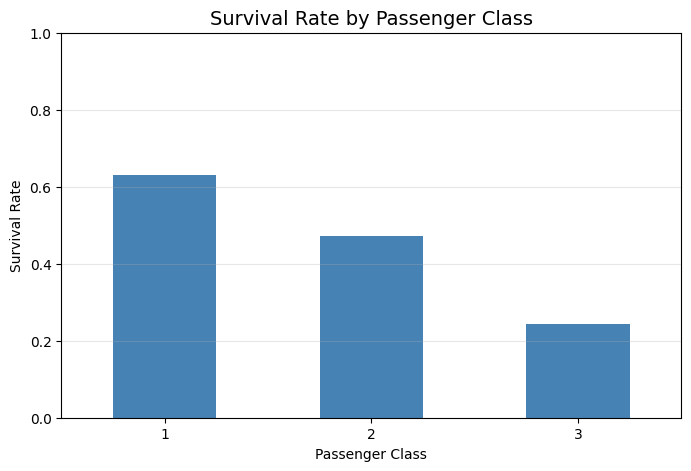

In [22]:
# Survival rate by class
survival_by_class.plot(kind='bar', color='steelblue', figsize=(8, 5))
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

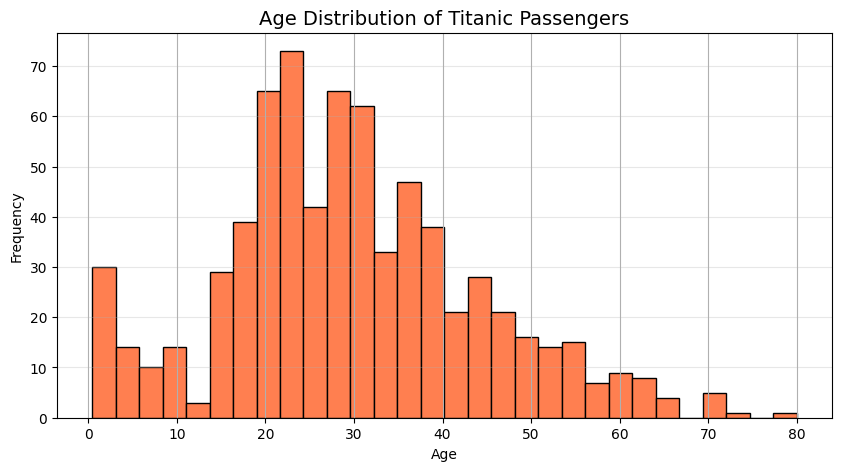

In [23]:
# Age distribution
df['age'].hist(bins=30, figsize=(10, 5), color='coral', edgecolor='black')
plt.title('Age Distribution of Titanic Passengers', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

---
## Part 3: NumPy Fundamentals  

### What is NumPy?

**NumPy** (Numerical Python) is the foundation of scientific computing in Python. It provides:
- **N-dimensional arrays** (ndarray)
- Fast mathematical operations
- Linear algebra, random number generation, and more

**Key fact:** Pandas is built on top of NumPy!

### Creating NumPy Arrays

In [24]:
# From a list
arr1 = np.array([1, 2, 3, 4, 5])
print("1D Array:", arr1)
print("Type:", type(arr1))
print("Shape:", arr1.shape)

1D Array: [1 2 3 4 5]
Type: <class 'numpy.ndarray'>
Shape: (5,)


In [25]:
# 2D array
arr2 = np.array([[1, 2, 3], [4, 5, 6]])
print("2D Array:")
print(arr2)
print("Shape:", arr2.shape)

2D Array:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)


In [26]:
# Special arrays
zeros = np.zeros((3, 4))
ones = np.ones((2, 3))
range_arr = np.arange(0, 10, 2)  # start, stop, step
linspace_arr = np.linspace(0, 1, 5)  # 5 evenly spaced numbers between 0 and 1

print("Zeros:\n", zeros)
print("\nOnes:\n", ones)
print("\nRange:", range_arr)
print("Linspace:", linspace_arr)

Zeros:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Ones:
 [[1. 1. 1.]
 [1. 1. 1.]]

Range: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]


### Converting Between Pandas and NumPy

In [27]:
# Get NumPy array from a pandas Series
ages_array = df['age'].values
print("Type:", type(ages_array))
print("First 10 ages:", ages_array[:10])

Type: <class 'numpy.ndarray'>
First 10 ages: [22. 38. 26. 35. 35. nan 54.  2. 27. 14.]


In [28]:
# Get NumPy array from entire DataFrame
numeric_data = df[['age', 'fare', 'sibsp', 'parch']].values
print("Shape:", numeric_data.shape)
print("\nFirst 5 rows:")
print(numeric_data[:5])

Shape: (891, 4)

First 5 rows:
[[22.      7.25    1.      0.    ]
 [38.     71.2833  1.      0.    ]
 [26.      7.925   0.      0.    ]
 [35.     53.1     1.      0.    ]
 [35.      8.05    0.      0.    ]]


### Array Operations

NumPy operations are **vectorized** - they operate on entire arrays at once, making them very fast!

In [30]:
# Basic math operations
arr = np.array([1, 2, 3, 4, 5])

print("Original:", arr)
print("Add 10:", arr + 10)
print("Multiply by 2:", arr * 2)
print("Square:", arr ** 2)
print("Square root:", np.sqrt(arr))

Original: [1 2 3 4 5]
Add 10: [11 12 13 14 15]
Multiply by 2: [ 2  4  6  8 10]
Square: [ 1  4  9 16 25]
Square root: [1.         1.41421356 1.73205081 2.         2.23606798]


In [31]:
# Array-to-array operations
arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])

print("arr1:", arr1)
print("arr2:", arr2)
print("Addition:", arr1 + arr2)
print("Element-wise multiplication:", arr1 * arr2)
print("Dot product:", np.dot(arr1, arr2))

arr1: [1 2 3]
arr2: [4 5 6]
Addition: [5 7 9]
Element-wise multiplication: [ 4 10 18]
Dot product: 32


### Statistical Operations

NumPy excels at numerical computations:

In [32]:
# Remove NaN values for clean calculations
ages_clean = df['age'].dropna().values

print(f"Mean age: {np.mean(ages_clean):.2f}")
print(f"Median age: {np.median(ages_clean):.2f}")
print(f"Std deviation: {np.std(ages_clean):.2f}")
print(f"Min age: {np.min(ages_clean):.2f}")
print(f"Max age: {np.max(ages_clean):.2f}")
print(f"25th percentile: {np.percentile(ages_clean, 25):.2f}")
print(f"75th percentile: {np.percentile(ages_clean, 75):.2f}")

Mean age: 29.70
Median age: 28.00
Std deviation: 14.52
Min age: 0.42
Max age: 80.00
25th percentile: 20.12
75th percentile: 38.00


### Boolean Indexing

In [33]:
# Filter arrays using conditions
ages_clean = df['age'].dropna().values

# Find children (age < 18)
children = ages_clean[ages_clean < 18]
print(f"Number of children: {len(children)}")
print(f"Average age of children: {np.mean(children):.2f}")

# Find seniors (age >= 60)
seniors = ages_clean[ages_clean >= 60]
print(f"\nNumber of seniors: {len(seniors)}")
print(f"Average age of seniors: {np.mean(seniors):.2f}")

Number of children: 113
Average age of children: 9.04

Number of seniors: 26
Average age of seniors: 65.10


### Practical Example: Normalizing Data

Let's normalize the fare data using NumPy (a common preprocessing step in machine learning):

In [34]:
# Get fare data (remove NaN values)
fares = df['fare'].dropna().values

# Z-score normalization: (x - mean) / std
fare_mean = np.mean(fares)
fare_std = np.std(fares)
fares_normalized = (fares - fare_mean) / fare_std

print(f"Original fares - Mean: {fare_mean:.2f}, Std: {fare_std:.2f}")
print(f"Normalized fares - Mean: {np.mean(fares_normalized):.2f}, Std: {np.std(fares_normalized):.2f}")

print("\nFirst 10 original fares:", fares[:10])
print("First 10 normalized fares:", fares_normalized[:10].round(2))

Original fares - Mean: 32.20, Std: 49.67
Normalized fares - Mean: 0.00, Std: 1.00

First 10 original fares: [ 7.25   71.2833  7.925  53.1     8.05    8.4583 51.8625 21.075  11.1333
 30.0708]
First 10 normalized fares: [-0.5   0.79 -0.49  0.42 -0.49 -0.48  0.4  -0.22 -0.42 -0.04]


### Random Number Generation

In [35]:
# Set seed for reproducibility
np.random.seed(42)

# Random integers
random_ints = np.random.randint(1, 100, size=10)
print("Random integers:", random_ints)

# Random floats (uniform distribution)
random_floats = np.random.rand(5)
print("Random floats (0-1):", random_floats.round(3))

# Random normal distribution
random_normal = np.random.randn(5)
print("Random normal:", random_normal.round(3))

Random integers: [52 93 15 72 61 21 83 87 75 75]
Random floats (0-1): [0.866 0.601 0.708 0.021 0.97 ]
Random normal: [-0.469  0.543 -0.463 -0.466  0.242]


### Why NumPy Matters

Let's see the speed difference between Python lists and NumPy arrays:

In [36]:
import time

# Create large dataset
size = 1000000
python_list = list(range(size))
numpy_array = np.arange(size)

# Python list operation
start = time.time()
result_list = [x * 2 for x in python_list]
list_time = time.time() - start

# NumPy array operation
start = time.time()
result_array = numpy_array * 2
numpy_time = time.time() - start

print(f"Python list time: {list_time:.4f} seconds")
print(f"NumPy array time: {numpy_time:.4f} seconds")
print(f"NumPy is {list_time/numpy_time:.1f}x faster!")

Python list time: 0.0591 seconds
NumPy array time: 0.0054 seconds
NumPy is 11.0x faster!


---
## Part 4: Bringing It All Together

Let's use all three tools (Jupyter, Pandas, NumPy) to answer an interesting question:

**"What factors most influenced survival on the Titanic?"**

In [37]:
# Create a comprehensive analysis
print("=" * 50)
print("TITANIC SURVIVAL ANALYSIS")
print("=" * 50)

# Overall survival rate
overall_survival = df['survived'].mean()
print(f"\nOverall survival rate: {overall_survival:.1%}")

# By gender
print("\n--- Survival by Gender ---")
gender_survival = df.groupby('sex')['survived'].agg(['mean', 'count'])
gender_survival.columns = ['Survival Rate', 'Count']
print(gender_survival)

# By class
print("\n--- Survival by Class ---")
class_survival = df.groupby('pclass')['survived'].agg(['mean', 'count'])
class_survival.columns = ['Survival Rate', 'Count']
print(class_survival)

# By age group
print("\n--- Survival by Age Group ---")
age_survival = df.groupby('age_group')['survived'].agg(['mean', 'count'])
age_survival.columns = ['Survival Rate', 'Count']
print(age_survival)

# Statistical insight using NumPy
survivors_age = df[df['survived'] == 1]['age'].dropna().values
non_survivors_age = df[df['survived'] == 0]['age'].dropna().values

print("\n--- Age Statistics ---")
print(f"Average age of survivors: {np.mean(survivors_age):.1f}")
print(f"Average age of non-survivors: {np.mean(non_survivors_age):.1f}")
print(f"Age difference: {np.mean(non_survivors_age) - np.mean(survivors_age):.1f} years")

TITANIC SURVIVAL ANALYSIS

Overall survival rate: 38.4%

--- Survival by Gender ---
        Survival Rate  Count
sex                         
female       0.742038    314
male         0.188908    577

--- Survival by Class ---
        Survival Rate  Count
pclass                      
1            0.629630    216
2            0.472826    184
3            0.242363    491

--- Survival by Age Group ---
           Survival Rate  Count
age_group                      
Child           0.579710     69
Teen            0.428571     70
Adult           0.388788    553
Senior          0.227273     22

--- Age Statistics ---
Average age of survivors: 28.3
Average age of non-survivors: 30.6
Age difference: 2.3 years


/var/folders/tk/ck9p69g578x913sym8lv3zp00000gn/T/ipykernel_31486/2713511294.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('age_group')['survived'].agg(['mean', 'count'])


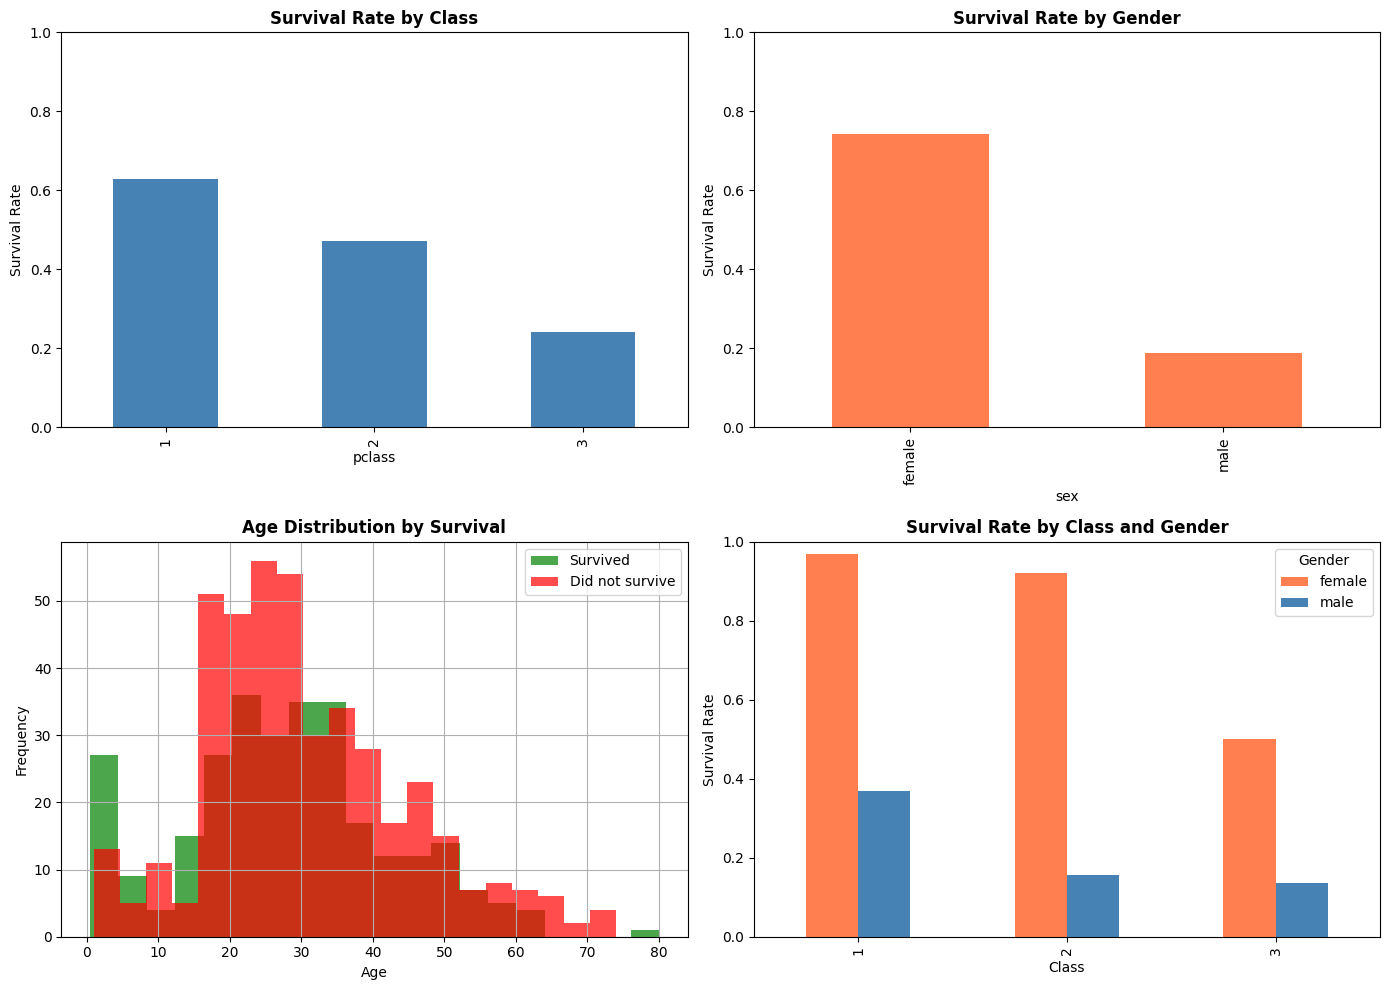

In [38]:
# Create a visualization summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Survival by class
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Survival Rate by Class', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_ylim(0, 1)

# Plot 2: Survival by gender
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Survival Rate by Gender', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_ylim(0, 1)

# Plot 3: Age distribution by survival
df[df['survived'] == 1]['age'].hist(bins=20, ax=axes[1,0], alpha=0.7, label='Survived', color='green')
df[df['survived'] == 0]['age'].hist(bins=20, ax=axes[1,0], alpha=0.7, label='Did not survive', color='red')
axes[1,0].set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Plot 4: Survival by class and gender
survival_matrix = df.groupby(['pclass', 'sex'])['survived'].mean().unstack()
survival_matrix.plot(kind='bar', ax=axes[1,1], color=['coral', 'steelblue'])
axes[1,1].set_title('Survival Rate by Class and Gender', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Survival Rate')
axes[1,1].set_xlabel('Class')
axes[1,1].legend(title='Gender')
axes[1,1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## Key Takeaways

### Jupyter Notebooks
- Interactive environment for data analysis
- Mix code, visualizations, and documentation
- Great for exploration and sharing results

### Pandas
- **DataFrames** are the core data structure
- Easy data loading, filtering, and manipulation
- Powerful grouping and aggregation capabilities
- Built-in visualization

### NumPy
- Foundation for numerical computing in Python
- Fast, vectorized operations on arrays
- Essential for scientific computing and machine learning
- Works seamlessly with Pandas

### Real Insight from the Data
From our Titanic analysis, we found that survival was strongly influenced by:
1. **Gender**: Women had much higher survival rates (~74% vs ~19% for men)
2. **Class**: First class passengers had better survival rates (~63% vs ~24% for third class)
3. **Age**: Children had slightly better survival rates
4. **"Women and children first"** was clearly followed!

---
## Next Steps

To continue your data science journey:

1. **Practice with different datasets**
   - UCI Machine Learning Repository
   - Kaggle datasets
   - Government data portals

2. **Learn more advanced topics**
   - Data visualization with Matplotlib and Seaborn
   - Machine learning with scikit-learn
   - Time series analysis
   - Web scraping

3. **Join the community**
   - Stack Overflow
   - Kaggle competitions
   - Local data science meetups

4. **Build projects**
   - Personal data analysis projects
   - Kaggle competitions
   - Contribute to open source

---

## Resources

- **Pandas Documentation**: https://pandas.pydata.org/docs/
- **NumPy Documentation**: https://numpy.org/doc/
- **Jupyter Documentation**: https://jupyter.org/documentation
- **Python Data Science Handbook** (free online): https://jakevdp.github.io/PythonDataScienceHandbook/

---

### Thank you! Questions?